# Pure-DIPF Controller — Annotated Walkthrough

This notebook explains, cell by cell, the potential-field logic implemented in
[`dipf_controller.py`](dipf_controller.py) (v2). It is **standalone** — every
function below is re-implemented in plain Python/NumPy so the notebook runs
without SUMO/TraCI. Parameter values are copied from `config.yaml` so the
plots reflect the real tuning.

The controller works in four stages, repeated every simulation step:

1. Build a scalar potential field $U_{total}(x,y)$: attractive toward the goal,
   repulsive from lane edges and from nearby vehicles.
2. Take $-\nabla U_{total}$ (numerically) as the desired acceleration, clamped
   to the vehicle's physical accel limits.
3. Integrate velocity/position with constant-acceleration kinematics.
4. Check the *proposed* new position for road-boundary and body-overlap
   collisions **before** committing it — if either fails, the step is a
   collision, never silently corrected.

We'll build up $U_{total}$ term by term, visualize each one, then show the
resulting gradient/acceleration field and the full per-step control logic.

## 0. Setup and parameters

Values below are taken directly from `config.yaml` for this project's
`straight3lane` scenario (3 lanes, 3.5 m wide, 1000 m road).

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

# --- simulation / road geometry (config.yaml: simulation, ego) ---
ROAD_LENGTH_M = 1000.0
LANES = 3
LANE_WIDTH_M = 3.5

EGO_LENGTH = 4.583
EGO_WIDTH = 1.748
EGO_MAX_SPEED = 30.0
EGO_A_MAX = 3.2
EGO_AY_MAX = 3.0
EGO_VY_MAX = 3.0

GOAL_LANE_INDEX = 0
GOAL_X_OFFSET = 15.0
EGO_GOAL_X = ROAD_LENGTH_M - GOAL_X_OFFSET

# --- Pure-DIPF parameters (config.yaml: dipf) ---
LAMBDA_OBS = 2000.0
ALPHA = 1.6422052478480245
TAU_X_BASE = 4.721871478710501
TAU_Y_BASE = 1.8648315932156687

SX = 1.0
SY = 1.0
DELTA_LANE = 400.0

W_DEST = 1.0
W_OBS = 1.0
W_LANE = 1.0

DV_MAX = 10.0          # dv_max_front fallback (see note in dipf_controller.py)
OBS_RADIUS_AHEAD = 50.0
OBS_RADIUS_BEHIND = 20.0
LATERAL_BAND = 8.0

GRAD_EPS = 0.05
Y_MARGIN = 0.1


def clamp(x, lo, hi):
    return lo if x < lo else hi if x > hi else x


def lane_centers_y():
    mid = (LANES - 1) / 2.0
    return [(i - mid) * LANE_WIDTH_M for i in range(LANES)]


def road_bounds_y():
    half = (LANES * LANE_WIDTH_M) / 2.0
    return -half, +half


def road_bounds_y_safe_for_ego():
    y_left, y_right = road_bounds_y()
    half_ego = 0.5 * EGO_WIDTH
    buf = 0.05
    y_min = y_left + half_ego + Y_MARGIN + buf
    y_max = y_right - half_ego - Y_MARGIN - buf
    return y_min, y_max, y_left, y_right


print('Lane centers (m):', lane_centers_y())
print('Road bounds (m):', road_bounds_y())
print('Goal:', EGO_GOAL_X, 'm, lane', GOAL_LANE_INDEX + 1, 'center y =', lane_centers_y()[GOAL_LANE_INDEX])


Lane centers (m): [-3.5, 0.0, 3.5]
Road bounds (m): (-5.25, 5.25)
Goal: 985.0 m, lane 1 center y = -3.5


## 1. Destination potential $U_{dest}$ (attractive)

$$U_{dest}(x,y) = \sqrt{s_x(x-x_d)^2 + s_y(y-y_d)^2}$$

A weighted Euclidean distance to the goal point $(x_d, y_d)$. $s_x, s_y$ let
you weight longitudinal vs. lateral pull independently — here both are 1, so
it's a plain Euclidean cone centered on the goal.

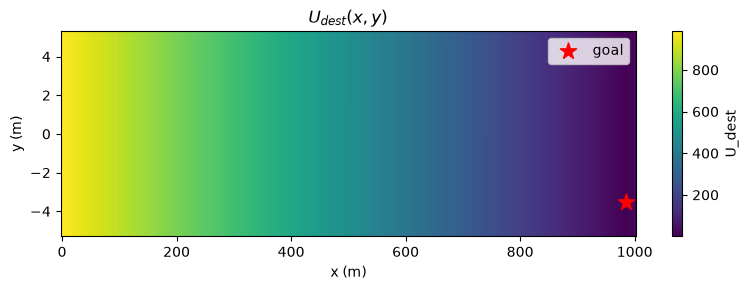

In [2]:
def U_dest(xh, yh, xd, yd):
    return math.sqrt(SX * (xh - xd) ** 2 + SY * (yh - yd) ** 2)

# Visualize as a function of y at a fixed x, and as a 2D cone
xs = np.linspace(0, ROAD_LENGTH_M, 200)
ys = np.linspace(*road_bounds_y(), 100)
X, Y = np.meshgrid(xs, ys)
goal_y = lane_centers_y()[GOAL_LANE_INDEX]
Z = np.sqrt(SX * (X - EGO_GOAL_X) ** 2 + SY * (Y - goal_y) ** 2)

fig, ax = plt.subplots(figsize=(8, 3))
c = ax.pcolormesh(X, Y, Z, shading='auto', cmap='viridis')
ax.scatter([EGO_GOAL_X], [goal_y], color='red', marker='*', s=150, label='goal')
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)'); ax.set_title('$U_{dest}(x,y)$')
fig.colorbar(c, ax=ax, label='U_dest')
ax.legend()
plt.tight_layout(); plt.show()


## 2. Lane-boundary potential $U_{lane}$ (repulsive)

$$U_{lane}(y) = \Delta_{lane}\left(\frac{1}{\max(\epsilon,\,y-y_{left})^2} + \frac{1}{\max(\epsilon,\,y_{right}-y)^2}\right)$$

This blows up as $y$ approaches either road edge. It is evaluated against
**shrunk "safe" bounds** ($y_{left}, y_{right}$ pulled inward by half the ego
width plus a margin) so the potential starts rising *before* the vehicle body
would actually reach the true edge — but note this is only used to *shape*
the field, never to clamp the applied position (see §5).

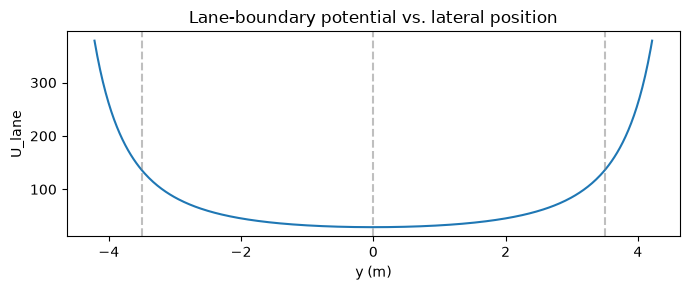

In [3]:
def U_lane(yh, y_left, y_right):
    eps = 1e-3
    return DELTA_LANE * (
        (1.0 / max(eps, yh - y_left)) ** 2
        + (1.0 / max(eps, y_right - yh)) ** 2
    )

y_min, y_max, y_left, y_right = road_bounds_y_safe_for_ego()
yy = np.linspace(y_min + 0.01, y_max - 0.01, 400)
uu = [U_lane(y, y_left, y_right) for y in yy]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(yy, uu)
for yc in lane_centers_y():
    ax.axvline(yc, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('y (m)'); ax.set_ylabel('U_lane'); ax.set_title('Lane-boundary potential vs. lateral position')
plt.tight_layout(); plt.show()


## 3. Obstacle potential $U_{obs}$ (repulsive, direction-agnostic)

This is the part the docstring in `dipf_controller.py` highlights as rewritten
in v2: instead of classifying an obstacle as front/rear/side and using a
different formula per case, a single closing-speed term is used regardless of
where the obstacle is.

**Relative state:** $D_x = x_o - x_h,\; D_y = y_o - y_h,\; D_{vx}=v_{xo}-v_{xh},\; D_{vy}=v_{yo}-v_{yh}$

**Gating:** $U_{obs}=0$ if $D_x >$ `OBS_RADIUS_AHEAD`, or $D_x < -$`OBS_RADIUS_BEHIND`,
or $|D_y| >$ `LATERAL_BAND`.

**Closing speed** (rate the gap $|\mathbf D|=\sqrt{D_x^2+D_y^2}$ is shrinking):
$$\Delta v = \max\!\left(0,\; -\frac{D_x D_{vx} + D_y D_{vy}}{|\mathbf D|}\right)$$
Zero (no repulsion) whenever the gap is constant or growing — this is what
makes the term direction-agnostic: a receding obstacle contributes nothing no
matter which side it's on.

$$f(\Delta v) = \mathrm{clamp}\!\left(\frac{\Delta v}{\Delta v_{max}},\,0,\,1\right)$$

**Directional time constants** (note: `tanh` argument is $D_v$ alone, not
$D_x \cdot D_{vx}$ — a deliberate fix vs. an earlier version):
$$\tau(D_v,\,\text{base}) = \text{base}\cdot\frac{(1+\alpha D_v) + (\alpha D_v - 1)\tanh(D_v)}{2}$$
applied as $\tau_x = \tau(D_{vx}, \tau_{x,base})$, $\tau_y = \tau(D_{vy}, \tau_{y,base})$.

**Shape term**, with combined half-extents $w_{eff}=\frac{W_{ego}+w_o}{2}$, $l_{eff}=\frac{L_{ego}+l_o}{2}$:

$$k'(D_x,D_y,D_{vx},D_{vy}) = \begin{cases}
\left(1-\dfrac{w_{eff}}{|D_x|}\right)\sqrt{\left(\dfrac{D_x}{\tau_x}\right)^2+\left(\dfrac{D_y}{\tau_y}\right)^2} & |D_y|\le \dfrac{l_{eff}}{w_{eff}}|D_x| \\[1.5ex]
\left(1-\dfrac{l_{eff}}{|D_y|}\right)\sqrt{\left(\dfrac{D_x}{\tau_x}\right)^2+\left(\dfrac{D_y}{\tau_y}\right)^2} & \text{otherwise}
\end{cases}$$

(each branch floored at 0.1; a final `+0.05` keeps $k'$ strictly positive).

**Final:**
$$U_{obs} = \lambda_{obs}\cdot\frac{f(\Delta v)}{k'}$$

In [4]:
def tau_component(delta_v, base):
    scale = 0.5 * ((1.0 + ALPHA * delta_v) + (ALPHA * delta_v - 1.0) * math.tanh(delta_v))
    return base * scale


def k_prime(dx, dy, dvx, dvy, w_eff, l_eff):
    tau_x = tau_component(dvx, TAU_X_BASE)
    tau_y = tau_component(dvy, TAU_Y_BASE)

    eps = 1e-3
    tau_x = tau_x if abs(tau_x) > eps else eps
    tau_y = tau_y if abs(tau_y) > eps else eps

    abs_dx = abs(dx) if abs(dx) > eps else eps
    abs_dy = abs(dy) if abs(dy) > eps else eps

    if abs_dy <= (l_eff * abs_dx) / w_eff:
        term = (1.0 - (w_eff / abs_dx)) if abs_dx > w_eff else 0.1
        term = max(0.1, term)
    else:
        term = (1.0 - (l_eff / abs_dy)) if abs_dy > l_eff else 0.1
        term = max(0.1, term)

    kp = term * math.sqrt((dx / tau_x) ** 2 + (dy / tau_y) ** 2)
    return kp + 0.05


def relative_closing_speed(dx, dy, dvx, dvy):
    dist = math.hypot(dx, dy)
    if dist < 1e-6:
        return 0.0
    closing = -(dx * dvx + dy * dvy) / dist
    return max(0.0, closing)


def U_obs_exact(xh, yh, vxh, vyh, xo, yo, vxo, vyo, w_eff=2.0, l_eff=5.0):
    dx = xo - xh
    dy = yo - yh
    dvx = vxo - vxh
    dvy = vyo - vyh

    if dx > OBS_RADIUS_AHEAD or dx < -OBS_RADIUS_BEHIND:
        return 0.0
    if abs(dy) > LATERAL_BAND:
        return 0.0

    delta_v = relative_closing_speed(dx, dy, dvx, dvy)
    f_dv = clamp(delta_v / max(1e-6, DV_MAX), 0.0, 1.0)
    if f_dv <= 0.0:
        return 0.0

    w_combined = (EGO_WIDTH + w_eff) / 2.0
    l_combined = (EGO_LENGTH + l_eff) / 2.0
    kp = k_prime(dx, dy, dvx, dvy, w_combined, l_combined)
    return LAMBDA_OBS * f_dv / kp

print('sanity check U_obs_exact:', U_obs_exact(0, 0, 20, 0, 15, 0, 15, 0))


sanity check U_obs_exact: 353.2329588360527


### 3a. Effect of closing speed $\Delta v$

An obstacle directly ahead, approached at increasing relative speed, produces
a monotonically increasing potential (until $f(\Delta v)$ saturates at 1).

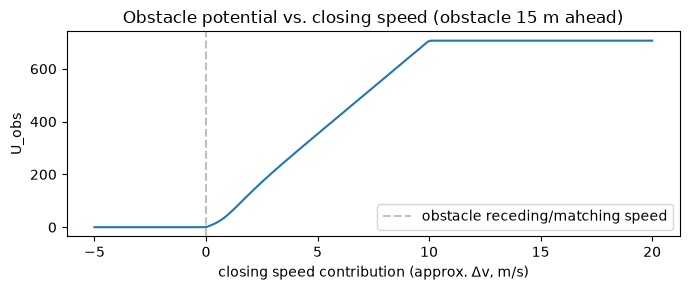

In [5]:
dv_range = np.linspace(-5, 20, 200)
Us = []
for dvx in dv_range:
    # ego at origin moving at 20 m/s, obstacle 15 m ahead moving slower/faster
    u = U_obs_exact(0, 0, 20, 0, 15, 0, 20 - dvx, 0)
    Us.append(u)

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(dv_range, Us)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5, label='obstacle receding/matching speed')
ax.set_xlabel('closing speed contribution (approx. Δv, m/s)')
ax.set_ylabel('U_obs')
ax.set_title('Obstacle potential vs. closing speed (obstacle 15 m ahead)')
ax.legend()
plt.tight_layout(); plt.show()


### 3b. Spatial shape of $U_{obs}$ around a single obstacle

Heatmap of $U_{obs}$ as a function of ego position, for one obstacle fixed at
$(x_o, y_o) = (500, 0)$ moving at 15 m/s while the ego approaches at 25 m/s
(a closing scenario).

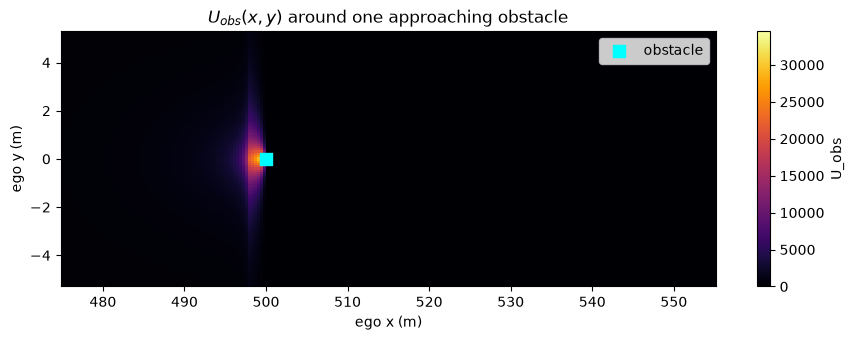

In [6]:
xo, yo, vxo, vyo = 500.0, 0.0, 15.0, 0.0
vxh, vyh = 25.0, 0.0

xs = np.linspace(xo - OBS_RADIUS_BEHIND - 5, xo + OBS_RADIUS_AHEAD + 5, 220)
ys = np.linspace(*road_bounds_y(), 120)
Uo = np.zeros((len(ys), len(xs)))
for i, yh in enumerate(ys):
    for j, xh in enumerate(xs):
        Uo[i, j] = U_obs_exact(xh, yh, vxh, vyh, xo, yo, vxo, vyo)

fig, ax = plt.subplots(figsize=(9, 3.5))
c = ax.pcolormesh(xs, ys, Uo, shading='auto', cmap='inferno')
ax.scatter([xo], [yo], color='cyan', marker='s', s=80, label='obstacle')
ax.set_xlabel('ego x (m)'); ax.set_ylabel('ego y (m)')
ax.set_title('$U_{obs}(x,y)$ around one approaching obstacle')
fig.colorbar(c, ax=ax, label='U_obs')
ax.legend()
plt.tight_layout(); plt.show()


## 4. Total potential and its gradient

$$U_{total}(x,y) = w_{dest}\,U_{dest} + w_{lane}\,U_{lane} + w_{obs}\sum_o U_{obs}^{(o)}$$

The gradient is computed **numerically** (central differences), not in closed
form — this keeps the controller agnostic to $U_{obs}$'s piecewise branch
structure:

$$\frac{\partial U}{\partial x} \approx \frac{U(x+\epsilon,y)-U(x-\epsilon,y)}{2\epsilon}, \qquad
\frac{\partial U}{\partial y} \approx \frac{U(x,y+\epsilon)-U(x,y-\epsilon)}{2\epsilon}$$

The desired acceleration is steepest descent, saturated at the vehicle's
physical limits — **the only** acceleration clamp applied anywhere in the
controller:

$$a_x = \mathrm{clamp}(-\partial U/\partial x,\, -a_{max},\, a_{max}), \qquad
a_y = \mathrm{clamp}(-\partial U/\partial y,\, -a_{y,max},\, a_{y,max})$$

In [7]:
def calculate_total_potential(x, y, vx, vy, obstacles, goal_x, goal_y):
    _, _, y_left, y_right = road_bounds_y_safe_for_ego()
    total = W_DEST * U_dest(x, y, goal_x, goal_y)
    total += W_LANE * U_lane(y, y_left, y_right)
    for (xo, yo, vxo, vyo, w_eff, l_eff) in obstacles:
        total += W_OBS * U_obs_exact(x, y, vx, vy, xo, yo, vxo, vyo, w_eff=w_eff, l_eff=l_eff)
    return total


def numerical_grad_U_total(state, obstacles, xd, yd):
    x, y, vx, vy = state

    def U_total(xx, yy):
        return calculate_total_potential(xx, yy, vx, vy, obstacles, xd, yd)

    eps = GRAD_EPS
    dUx = (U_total(x + eps, y) - U_total(x - eps, y)) / (2.0 * eps)
    dUy = (U_total(x, y + eps) - U_total(x, y - eps)) / (2.0 * eps)
    return dUx, dUy


def desired_accel(dUx, dUy):
    ax = clamp(-dUx, -EGO_A_MAX, EGO_A_MAX)
    ay = clamp(-dUy, -EGO_AY_MAX, EGO_AY_MAX)
    return ax, ay

# One obstacle blocking the goal lane, ego approaching
obstacles = [(600.0, lane_centers_y()[GOAL_LANE_INDEX], 12.0, 0.0, 2.1, 5.0)]
state = (500.0, lane_centers_y()[1], 22.0, 0.0)  # ego in middle lane
dUx, dUy = numerical_grad_U_total(state, obstacles, EGO_GOAL_X, lane_centers_y()[GOAL_LANE_INDEX])
ax_, ay_ = desired_accel(dUx, dUy)
print(f'gradient = ({dUx:.3f}, {dUy:.3f})  ->  desired accel = ({ax_:.3f}, {ay_:.3f})')


gradient = (-1.000, 0.007)  ->  desired accel = (1.000, -0.007)


### 4a. Full field + quiver plot

Total potential heatmap with the ($-\nabla U$, i.e. commanded acceleration
direction) vector field overlaid, for the same one-obstacle scenario. Ego
velocity is fixed at 22 m/s for the purpose of evaluating $U_{obs}$ (the field
is a function of *position* only, at a given velocity snapshot).

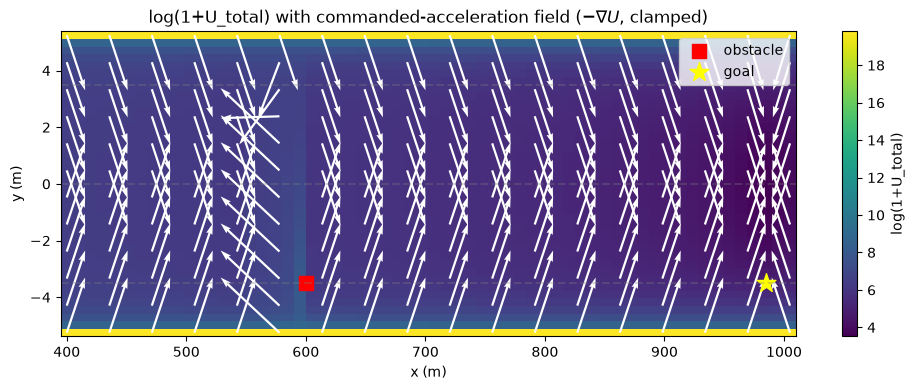

In [8]:
xs = np.linspace(400, EGO_GOAL_X + 20, 60)
ys = np.linspace(*road_bounds_y(), 40)
Xg, Yg = np.meshgrid(xs, ys)
Ug = np.zeros_like(Xg)
for i in range(Xg.shape[0]):
    for j in range(Xg.shape[1]):
        Ug[i, j] = calculate_total_potential(Xg[i, j], Yg[i, j], 22.0, 0.0, obstacles, EGO_GOAL_X, lane_centers_y()[GOAL_LANE_INDEX])

# quiver on a coarser grid
xq = np.linspace(400, EGO_GOAL_X + 20, 18)
yq = np.linspace(*road_bounds_y(), 12)
U_q = np.zeros((len(yq), len(xq)))
V_q = np.zeros((len(yq), len(xq)))
for i, yv in enumerate(yq):
    for j, xv in enumerate(xq):
        gx, gy = numerical_grad_U_total((xv, yv, 22.0, 0.0), obstacles, EGO_GOAL_X, lane_centers_y()[GOAL_LANE_INDEX])
        axv, ayv = desired_accel(gx, gy)
        U_q[i, j], V_q[i, j] = axv, ayv

fig, ax = plt.subplots(figsize=(10, 4))
c = ax.pcolormesh(Xg, Yg, np.log1p(Ug), shading='auto', cmap='viridis')
ax.quiver(xq, yq, U_q, V_q, color='white', scale=40, width=0.003)
ax.scatter([obstacles[0][0]], [obstacles[0][1]], color='red', marker='s', s=100, label='obstacle')
ax.scatter([EGO_GOAL_X], [lane_centers_y()[GOAL_LANE_INDEX]], color='yellow', marker='*', s=200, label='goal')
for yc in lane_centers_y():
    ax.axhline(yc, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('x (m)'); ax.set_ylabel('y (m)')
ax.set_title('log(1+U_total) with commanded-acceleration field ($-\\nabla U$, clamped)')
fig.colorbar(c, ax=ax, label='log(1+U_total)')
ax.legend()
plt.tight_layout(); plt.show()


## 5. Kinematic integration — and why there is no boundary clamp

Semi-implicit Euler on velocity, constant-acceleration kinematics on position:

$$v_x^{new} = \mathrm{clamp}(v_x + a_x\,dt,\, 0,\, v_{max}), \qquad
v_y^{new} = \mathrm{clamp}(v_y + a_y\,dt,\, -v_{y,max},\, v_{y,max})$$

$$x_{new} = x + v_x\,dt + \tfrac12 a_x\,dt^2, \qquad
y_{new} = y + v_y\,dt + \tfrac12 a_y\,dt^2$$

**Key design decision:** if $(x_{new}, y_{new})$ would put any part of the
ego's rectangular body outside the *true* road edges, the step is treated as
a **collision** — position is never clamped back onto the road. Silently
clamping would be equivalent to an unmodeled, unbounded correction that could
violate the declared $a_{max}$/$a_{y,max}$ without it ever showing up in the
logged accelerations.

In [9]:
def ego_within_road(x, y):
    y_left, y_right = road_bounds_y()
    half_w = EGO_WIDTH / 2.0
    half_l = EGO_LENGTH / 2.0
    if (y - half_w) < y_left or (y + half_w) > y_right:
        return False
    if (x - half_l) < 0.0 or (x + half_l) > ROAD_LENGTH_M:
        return False
    return True


def ego_body_collision(ego_x, ego_y, obstacles_full):
    # obstacles_full entries: (xo, yo, vxo, vyo, w_eff, l_eff, w_actual, l_actual)
    half_l_ego = EGO_LENGTH / 2.0
    half_w_ego = EGO_WIDTH / 2.0
    for (xo, yo, vxo, vyo, w_eff, l_eff, w_actual, l_actual) in obstacles_full:
        half_l_obs = l_actual / 2.0
        half_w_obs = w_actual / 2.0
        if (abs(ego_x - xo) < (half_l_ego + half_l_obs)
                and abs(ego_y - yo) < (half_w_ego + half_w_obs)):
            return True
    return False


def step_ego(x, y, vx, vy, obstacles, obstacles_full, dt, goal_x, goal_y):
    """One control step. Returns (status, x_new, y_new, vx_new, vy_new, ax, ay)."""
    dUx, dUy = numerical_grad_U_total((x, y, vx, vy), obstacles, goal_x, goal_y)
    ax, ay = desired_accel(dUx, dUy)

    vx_new = clamp(vx + ax * dt, 0.0, EGO_MAX_SPEED)
    vy_new = clamp(vy + ay * dt, -EGO_VY_MAX, EGO_VY_MAX)

    x_new = x + vx * dt + 0.5 * ax * dt * dt
    y_new = y + vy * dt + 0.5 * ay * dt * dt

    if not ego_within_road(x_new, y_new):
        return "COLLISION", x, y, vx, vy, ax, ay
    if ego_body_collision(x_new, y_new, obstacles_full):
        return "COLLISION", x, y, vx, vy, ax, ay

    return "OK", x_new, y_new, vx_new, vy_new, ax, ay


## 6. Putting it together: a small closed-loop simulation

No SUMO here — just the potential field driving a point-mass kinematic model,
with one obstacle merging in front of the ego in the goal lane. This
reproduces the same per-step logic as `ego_control_step` in
`dipf_controller.py`, minus the TraCI I/O.

final status: OK  steps run: 400


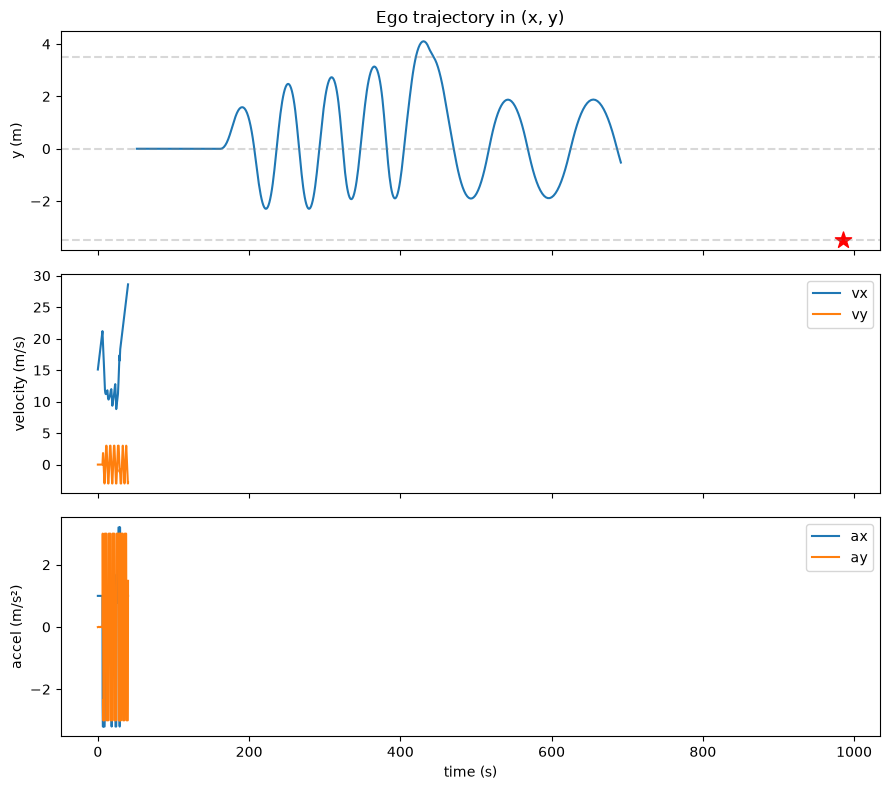

In [10]:
dt = 0.1
T = 40.0
steps = int(T / dt)

goal_y = lane_centers_y()[GOAL_LANE_INDEX]

x, y = 50.0, lane_centers_y()[1]
vx, vy = 15.0, 0.0

# a slower obstacle sitting in the goal lane ahead
obs_x0, obs_y0, obs_v = 150.0, goal_y, 10.0

traj = []
status = "OK"
for i in range(steps):
    t = i * dt
    ox = obs_x0 + obs_v * t
    obstacles = [(ox, obs_y0, obs_v, 0.0, 2.1, 5.0)]
    obstacles_full = [(ox, obs_y0, obs_v, 0.0, 2.1, 5.0, 1.8, 4.5)]

    if abs(x - EGO_GOAL_X) <= 1.5:
        status = "DONE"
        traj.append((t, x, y, vx, vy, 0.0, 0.0))
        break

    status, x, y, vx, vy, ax, ay = step_ego(x, y, vx, vy, obstacles, obstacles_full, dt, EGO_GOAL_X, goal_y)
    traj.append((t, x, y, vx, vy, ax, ay))
    if status == "COLLISION":
        break

traj = np.array(traj)
print('final status:', status, ' steps run:', len(traj))

fig, axes = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
axes[0].plot(traj[:, 1], traj[:, 2])
for yc in lane_centers_y():
    axes[0].axhline(yc, color='gray', linestyle='--', alpha=0.3)
axes[0].scatter([EGO_GOAL_X], [goal_y], color='red', marker='*', s=150)
axes[0].set_ylabel('y (m)'); axes[0].set_title('Ego trajectory in (x, y)')

axes[1].plot(traj[:, 0], traj[:, 3], label='vx')
axes[1].plot(traj[:, 0], traj[:, 4], label='vy')
axes[1].set_ylabel('velocity (m/s)'); axes[1].legend()

axes[2].plot(traj[:, 0], traj[:, 5], label='ax')
axes[2].plot(traj[:, 0], traj[:, 6], label='ay')
axes[2].set_ylabel('accel (m/s²)'); axes[2].set_xlabel('time (s)'); axes[2].legend()

plt.tight_layout(); plt.show()


## 7. Collision / termination taxonomy

Summarized from `ego_control_step` and `run_simulation` in
`dipf_controller.py`:

| Condition | Result |
|---|---|
| SUMO's native collision detector fires | `"collision"` |
| Ego within goal tolerance | `"success"` (unless the final snap-to-goal move itself collides) |
| Obstacle center within `COLLISION_RADIUS` of current ego position | `"COLLISION"` |
| Proposed new position exits true road bounds | `"COLLISION"` (never clamped) |
| Proposed new position's rectangle overlaps an obstacle's real rectangle | `"COLLISION"` |
| `moveToXY` itself throws a collision exception | `"COLLISION"` |
| `moveToXY` throws any other exception | `RuntimeError` raised — simulation aborts, not swallowed |
| Sim reaches `SIM_END`, no goal/collision, but not "stuck" | `"timeout"` |
| Sim reaches end/terminates, low avg speed + low net x-progress over trailing window | `"stuck"` |

Notes on design intent baked into the real controller (not reproduced in the
mini-simulation above, since they require SUMO/TraCI):

- `setSpeedMode(ego, 0)` and `setLaneChangeMode(ego, 0)` strip out SUMO's
  built-in car-following/lane-change control so the DIPF gradient has full
  authority over the ego's motion.
- The body-overlap check uses the obstacle's *actual* SUMO length/width
  (`w_actual`, `l_actual`), distinct from the padded `w_eff`/`l_eff` used only
  to shape the potential field — the padding is a *soft* safety margin, the
  actual dimensions are the *hard* collision test.
- A `check_local_minima` diagnostic samples the field on a ring around the
  ego and flags a likely local minimum (low gradient, all neighbors higher
  potential, still far from goal) purely for logging — it does not trigger
  any escape maneuver in the control law itself.